# End-to-End Car Price Prediction: EDA, Feature Engineering & Machine Learning

#### Introduction

Regression is a supervised learning technique used to analyze the relationship between two or more variables. In this project, we will explore regression models in depth and evaluate their performance on a real-world dataset.

As a practical example, we will develop a machine learning model to predict car prices based on various features. Our goal is to achieve a model performance with an R² score above 85%, ensuring strong predictive capability.

##### Dataset Overview

The dataset consists of 804 samples and includes the following features:

Price (Target variable)
Mileage
Make, Model, Trim, Type
Cylinder, Liter
Doors, Cruise, Sound, Leather

These features provide both numerical and categorical information, allowing us to build and compare a wide range of regression models.

##### Model Performance Summary

We evaluated 21 different regression models to identify the best-performing approach.

The CatBoost Regressor achieved the highest performance with an R² score of 0.995, significantly outperforming other models.
Linear models such as Lasso, Ridge, and Bayesian Ridge also performed strongly, achieving R² scores above 0.99.
Tree-based and ensemble models like Random Forest and Gradient Boosting showed solid performance but were slightly less accurate.
Some models, including ElasticNet and SVR, performed poorly, indicating that they are not well-suited for this dataset.

Overall, the results demonstrate that advanced ensemble methods, particularly CatBoost, are highly effective for structured tabular data.

### Importing Libraries

In [1]:
import pandas as pd  # Library for reading and handling data files
import sqlite3       # Used to read data from a database
import matplotlib.pyplot as plt  # Data visualization library
import seaborn as sns  # Advanced and aesthetically pleasing data visualization

In [2]:
conn=sqlite3.connect('cars.db') # connect database  (json,xml,csv,txt)

In [3]:
df=pd.read_sql_query('select * from cars',conn)

In [4]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221.0,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135.0,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196.0,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342.0,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832.0,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [5]:
#pip install xlrd 

In [6]:
df=pd.read_excel('cars.xls')

### EDA Exploratory Data Analysis

In [7]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [8]:
df.sample()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
498,18063.004911,27574,Pontiac,Bonneville,SE Sedan 4D,Sedan,6,3.8,4,1,0,0


In [9]:
df.sample(2)

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
136,36633.633819,22042,Cadillac,STS-V6,Sedan 4D,Sedan,6,3.6,4,1,1,1
444,16507.070267,17451,Chevrolet,Malibu,Sedan 4D,Sedan,6,3.5,4,0,1,1


In [10]:
df.tail()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
799,16507.070267,16229,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0
800,16175.957604,19095,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
801,15731.132897,20484,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
802,15118.893228,25979,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
803,13585.636802,35662,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     804 non-null    float64
 1   Mileage   804 non-null    int64  
 2   Make      804 non-null    object 
 3   Model     804 non-null    object 
 4   Trim      804 non-null    object 
 5   Type      804 non-null    object 
 6   Cylinder  804 non-null    int64  
 7   Liter     804 non-null    float64
 8   Doors     804 non-null    int64  
 9   Cruise    804 non-null    int64  
 10  Sound     804 non-null    int64  
 11  Leather   804 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 75.5+ KB


In [12]:
df.isnull().sum()

Price       0
Mileage     0
Make        0
Model       0
Trim        0
Type        0
Cylinder    0
Liter       0
Doors       0
Cruise      0
Sound       0
Leather     0
dtype: int64

In [14]:
df['Make'].value_counts() # Shows how many times each value appears in a column

Make
Chevrolet    320
Pontiac      150
SAAB         114
Buick         80
Cadillac      80
Saturn        60
Name: count, dtype: int64

In [15]:
df['Make'].unique()

array(['Buick', 'Cadillac', 'Chevrolet', 'Pontiac', 'SAAB', 'Saturn'],
      dtype=object)

In [16]:
df['Make'].nunique() # number of unique

6

In [17]:
df['Make'].value_counts(normalize=True)  # gives % 

Make
Chevrolet    0.398010
Pontiac      0.186567
SAAB         0.141791
Buick        0.099502
Cadillac     0.099502
Saturn       0.074627
Name: proportion, dtype: float64

In [19]:
df.describe()  # statistical functions (max, min, mean, etc.)

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
count,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000
mean,21343.143767,19831.934080,5.268657,3.037313,3.527363,0.752488,0.679104,0.723881
std,9884.852801,8196.319707,1.387531,1.105562,0.850169,0.431836,0.467111,0.447355
min,8638.930895,266.000000,4.000000,1.600000,2.000000,0.000000,0.000000,0.000000
25%,14273.073870,14623.500000,4.000000,2.200000,4.000000,1.000000,0.000000,0.000000
50%,18024.995019,20913.500000,6.000000,2.800000,4.000000,1.000000,1.000000,1.000000
75%,26717.316636,25213.000000,6.000000,3.800000,4.000000,1.000000,1.000000,1.000000
max,70755.466717,50387.000000,8.000000,6.000000,4.000000,1.000000,1.000000,1.000000


In [20]:
df.columns

Index(['Price', 'Mileage', 'Make', 'Model', 'Trim', 'Type', 'Cylinder',
       'Liter', 'Doors', 'Cruise', 'Sound', 'Leather'],
      dtype='object')

In [21]:
df.corr(numeric_only=True) # Calculates the correlation of each column with every other column

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
Price,1.000000,-0.143051,0.569086,0.558146,-0.138750,0.430851,-0.124348,0.157197
Mileage,-0.143051,1.000000,-0.029461,-0.018641,-0.016944,0.025037,-0.026146,0.001005
Cylinder,0.569086,-0.029461,1.000000,0.957897,0.002206,0.354285,-0.089704,0.075520
Liter,0.558146,-0.018641,0.957897,1.000000,-0.079259,0.377509,-0.065527,0.087332
Doors,-0.138750,-0.016944,0.002206,-0.079259,1.000000,-0.047674,-0.062530,-0.061969
Cruise,0.430851,0.025037,0.354285,0.377509,-0.047674,1.000000,-0.091730,-0.070573
Sound,-0.124348,-0.026146,-0.089704,-0.065527,-0.062530,-0.091730,1.000000,0.165444
Leather,0.157197,0.001005,0.075520,0.087332,-0.061969,-0.070573,0.165444,1.000000


In [22]:
# Golden rule: 0.20 < r < 0.90
# We typically avoid correlations above 0.90 because it indicates strong multicollinearity,
# meaning the information is essentially duplicated in another form.

In [30]:
# Heatmap: visual representation of the correlation matrix.
# cmap='tab10' changes the color palette of the plot.
# If correlation exceeds 0.90, it may indicate duplicated or highly similar information (multicollinearity),
# so such features should be considered for removal to improve model performance.
# A variable is perfectly correlated with itself, so the correlation value is always 1.

<Axes: >

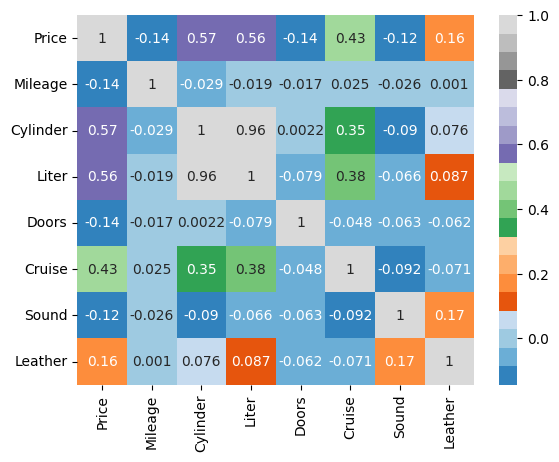

In [31]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='tab20c')

#### Data Visualization

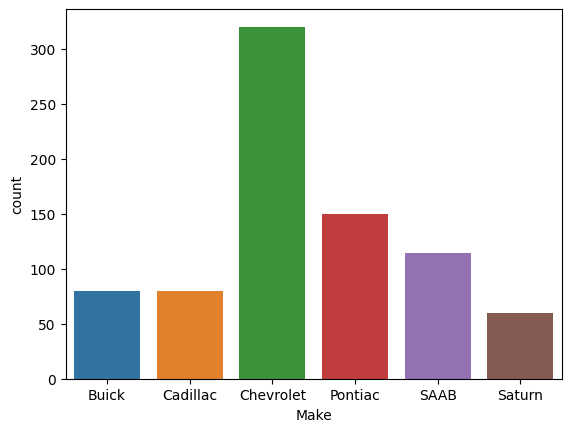

In [32]:
sns.countplot(x=df['Make'],hue=df['Make']);

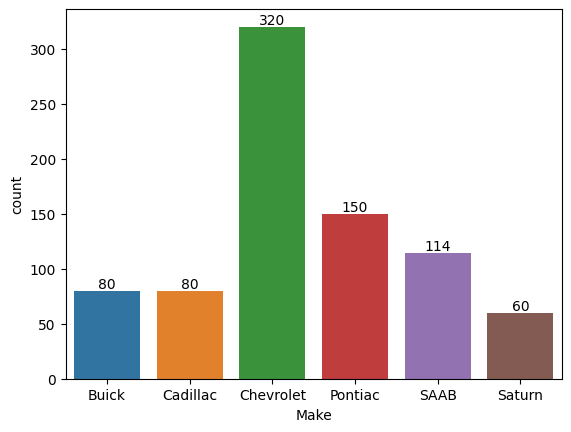

In [33]:
ax=sns.countplot(x=df['Make'],hue=df['Make'])
for container in ax.containers:
    ax.bar_label(container)

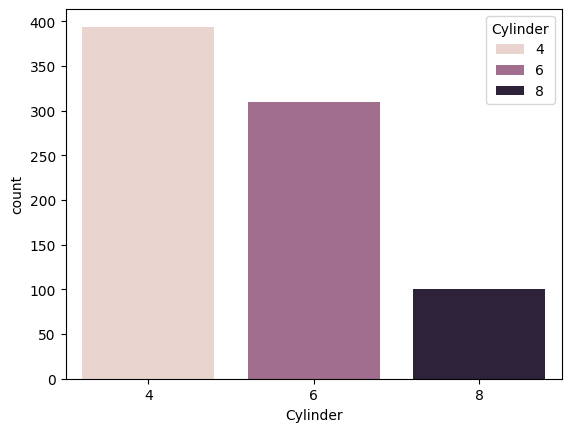

In [27]:
sns.countplot(x=df['Cylinder'],hue=df['Cylinder']);

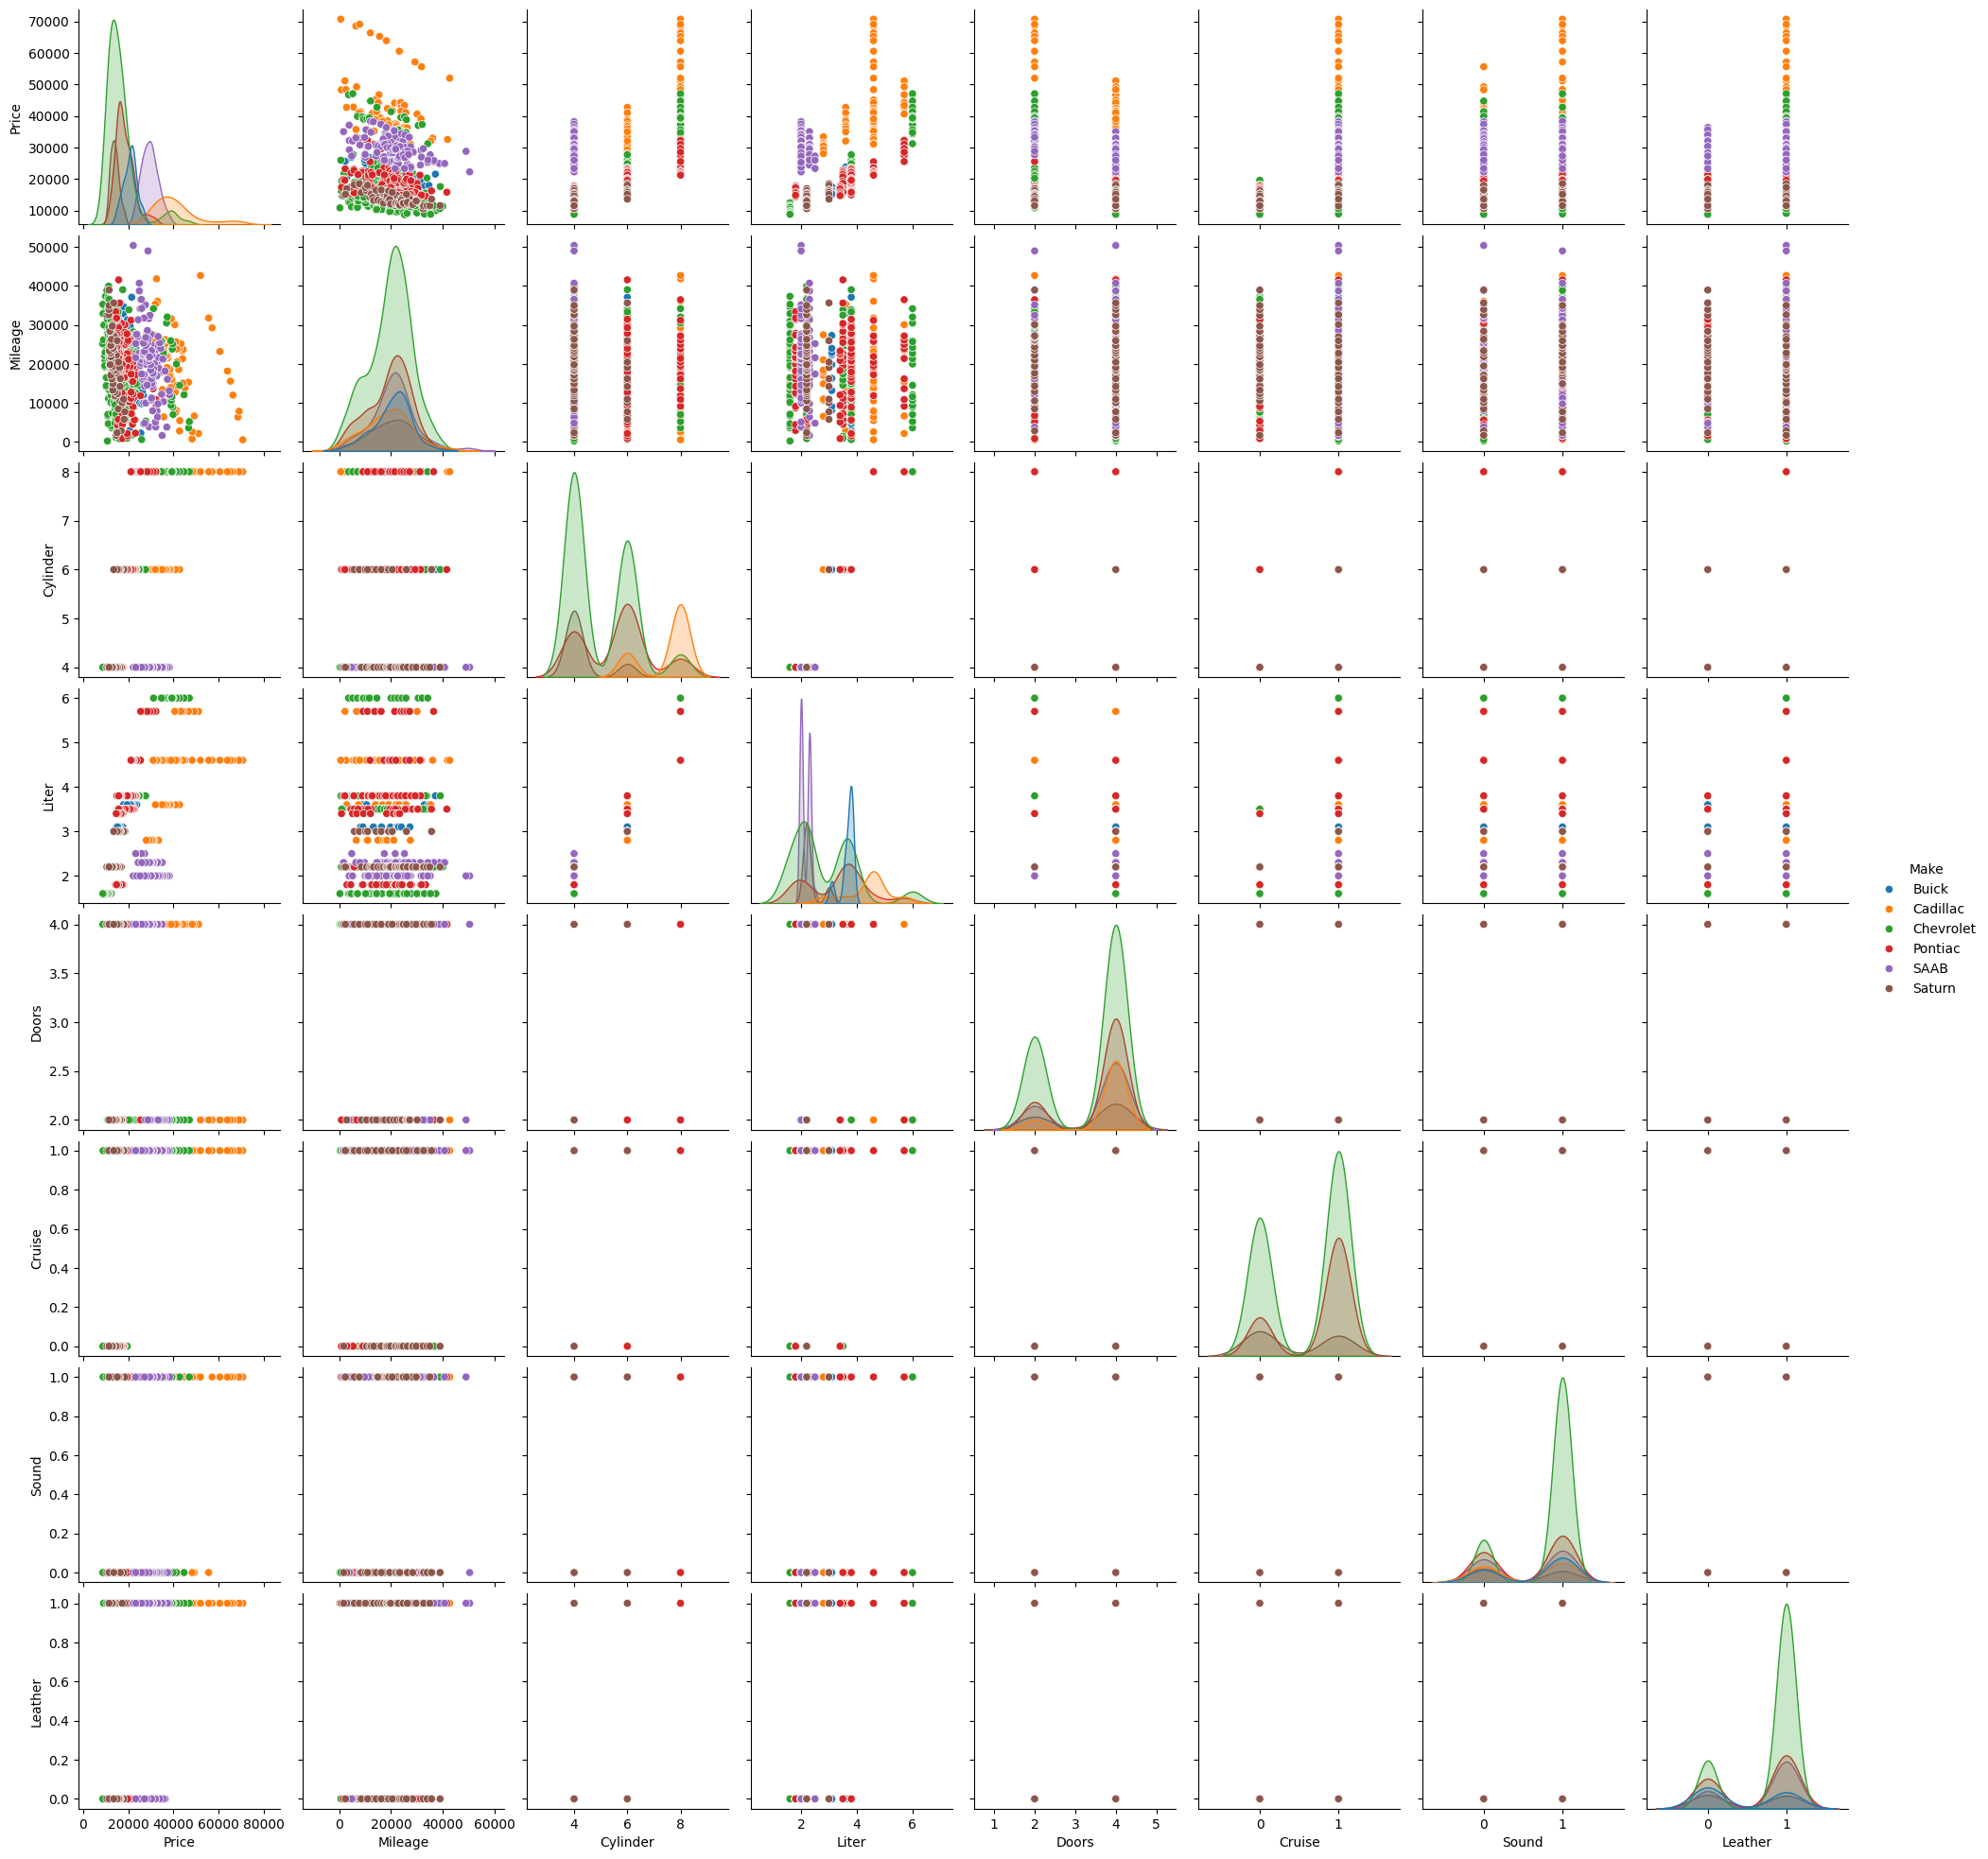

In [28]:
sns.pairplot(df,hue='Make')

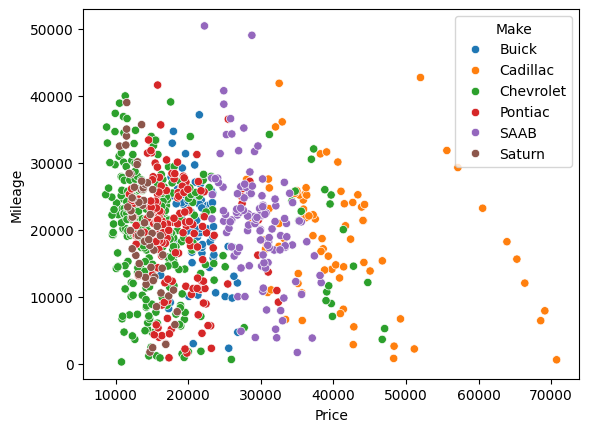

In [29]:
sns.scatterplot(x=df['Price'],y=df['Mileage'],hue=df['Make']);
# Plots the relationship between mileage and price.
# hue=df['Make'] is used to color the points based on the number of make.
# palette='muted' is used to make the colors more visually appealing and less harsh.

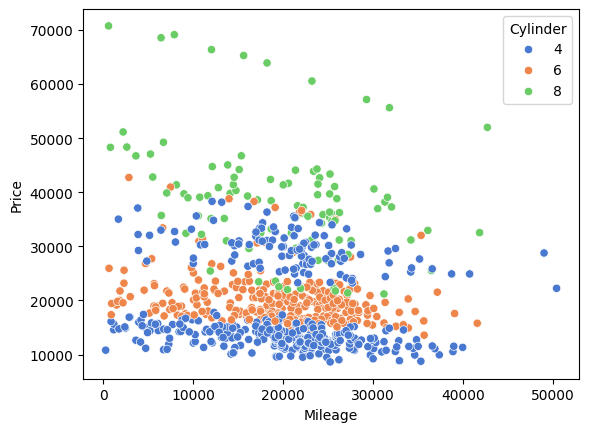

In [34]:
sns.scatterplot(x=df['Mileage'],y=df['Price'],hue=df['Cylinder'],palette='muted');
# Plots the relationship between mileage and price.
# hue=df['Cylinder'] is used to color the points based on the number of cylinders.
# palette='muted' is used to make the colors more visually appealing and less harsh.

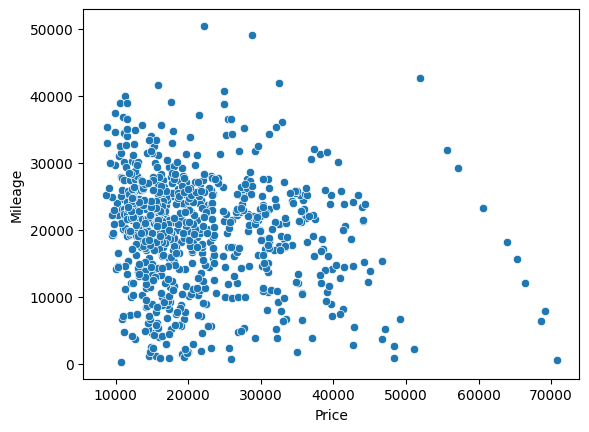

In [35]:
sns.scatterplot(x=df['Price'],y=df['Mileage']);

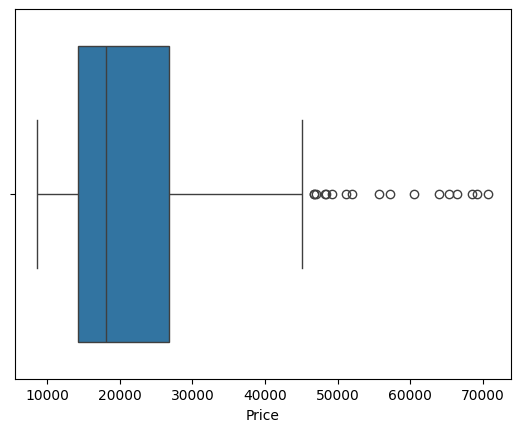

In [47]:
sns.boxplot(x=df["Price"]);
# Outlier formula: [mean ± 3 × standard deviation]. Values outside this range are considered outliers.

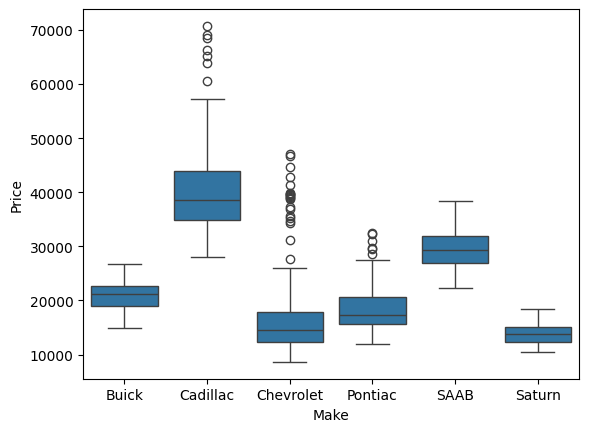

In [46]:
sns.boxplot(x=df['Make'],y=df['Price']);
#To analyze which car brands have more outliers based on their distribution.

#### P Value

In [178]:
# Null Hypothesis (H0):
# There is no relationship between a car's mileage and its price.

# Alternative Hypothesis (HA):
# There is a relationship between a car's mileage and its price.

# Decision Rule:
# Calculate the p-value.
# If p < 0.05, reject the null hypothesis (H0) and accept the alternative hypothesis (HA).
# If p > 0.05, fail to reject the null hypothesis (H0).

In [55]:
from scipy.stats import ttest_ind

In [56]:
t,p=ttest_ind(df['Price'],df['Mileage'])

In [57]:
p

0.0008662338227446262

In [58]:
p<0.05

True

In [37]:
# Conclusion: There is a relationship between a car’s price and its mileage

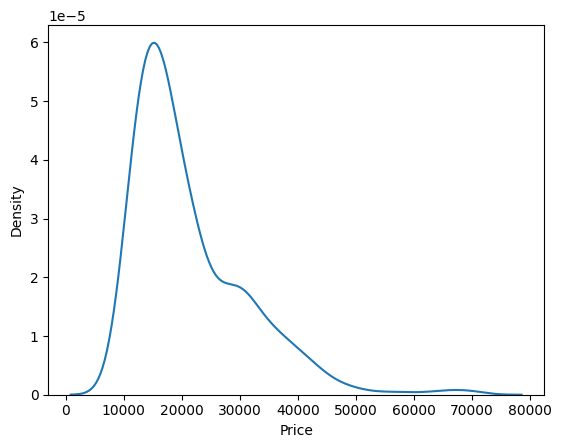

In [42]:
sns.kdeplot(x=df['Price']) ;
# Scatter plot (distribution plot).

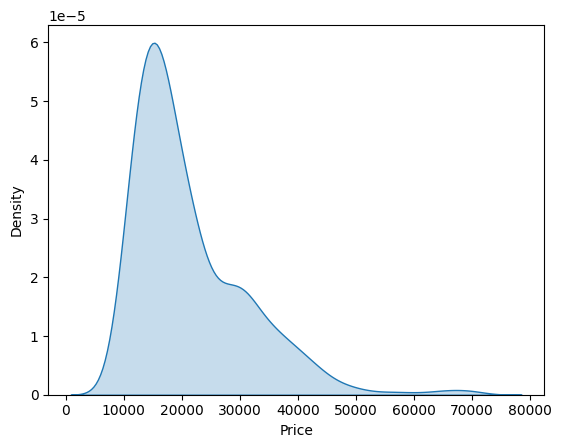

In [40]:
sns.kdeplot(x=df['Price'],fill=True);

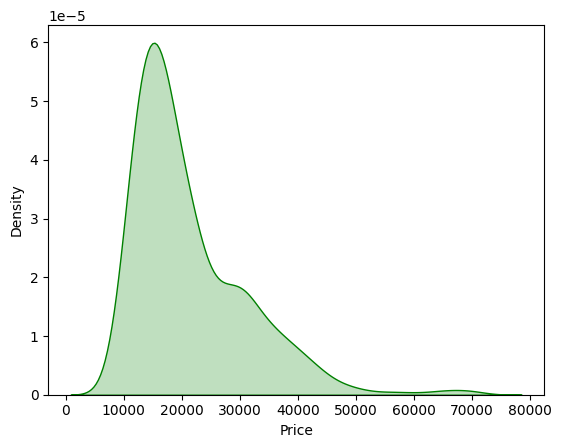

In [43]:
sns.kdeplot(x=df['Price'],fill=True, color='green');
# color='' fills the plot area with color.

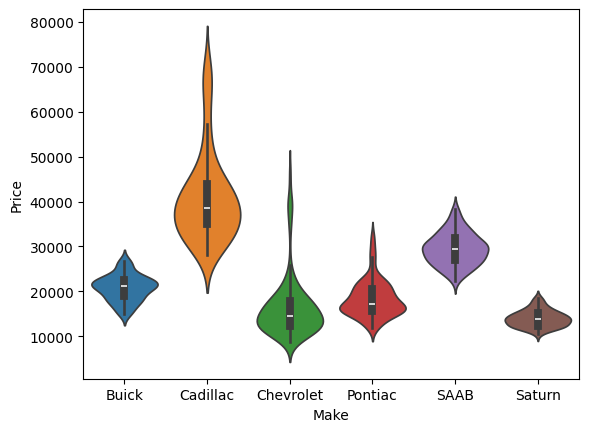

In [44]:
sns.violinplot(x='Make',y='Price',data=df,hue='Make');
#If multiple values are provided, they must be placed inside square brackets.

In [69]:
import plotly.express as px

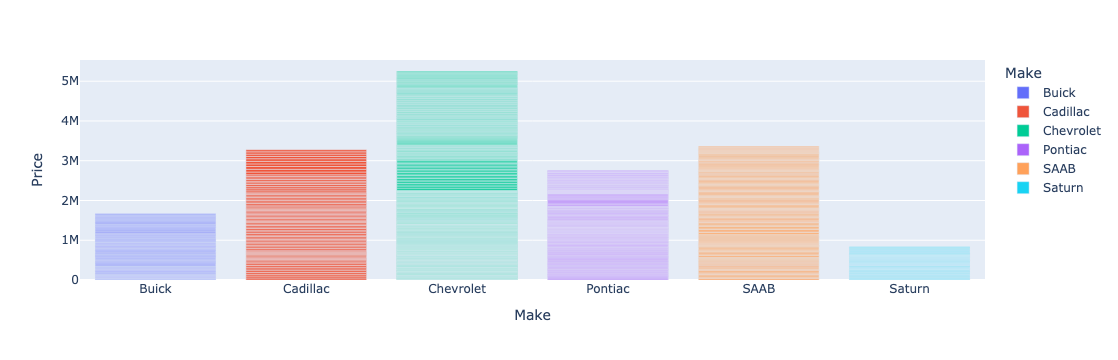

In [70]:
px.bar(df,x='Make',y='Price',color='Make')

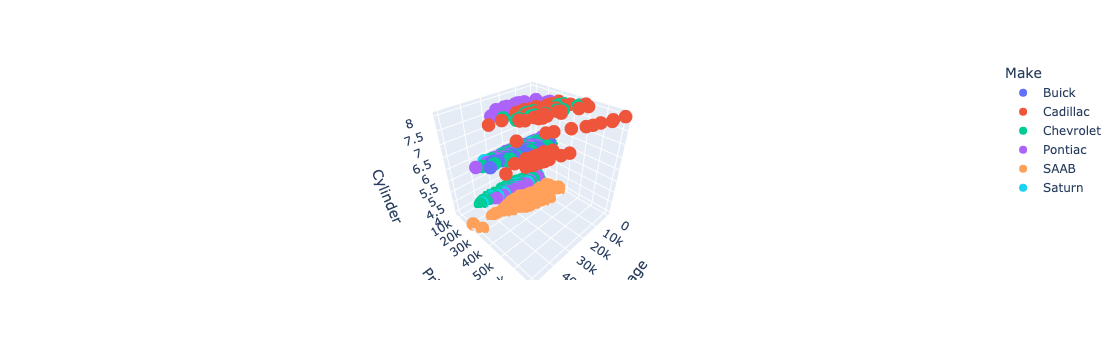

In [71]:
px.scatter_3d(df,x='Mileage',y='Price',color='Make',z='Cylinder')

In [75]:
px.sunburst(df,path=['Make','Model','Trim'],values='Price',width=800,height=600);

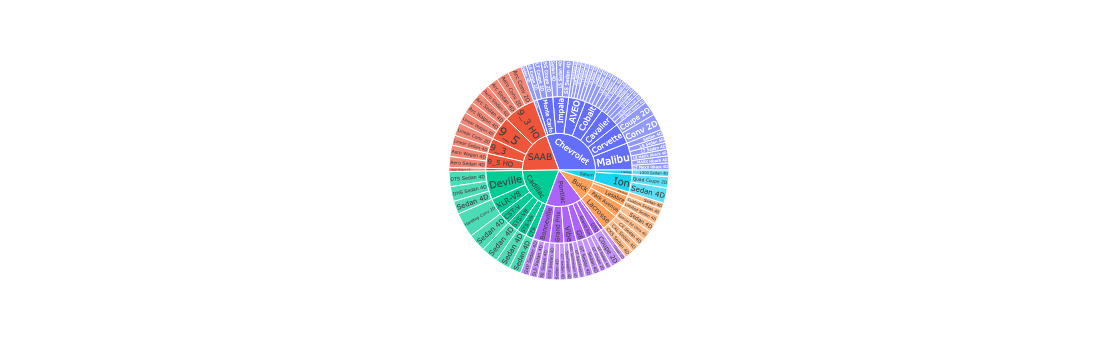

In [76]:
fig = px.sunburst(
    df,
    path=['Make', 'Model', 'Trim'],
    values='Price',
    hover_data=['Price']
)

fig.show()

### Feature Engineering

In [48]:
# Feature engineering is the process of creating new features (columns) from existing data that were not originally present in the dataset.

In [49]:
df.corr(numeric_only=True)

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
Price,1.000000,-0.143051,0.569086,0.558146,-0.138750,0.430851,-0.124348,0.157197
Mileage,-0.143051,1.000000,-0.029461,-0.018641,-0.016944,0.025037,-0.026146,0.001005
Cylinder,0.569086,-0.029461,1.000000,0.957897,0.002206,0.354285,-0.089704,0.075520
Liter,0.558146,-0.018641,0.957897,1.000000,-0.079259,0.377509,-0.065527,0.087332
Doors,-0.138750,-0.016944,0.002206,-0.079259,1.000000,-0.047674,-0.062530,-0.061969
Cruise,0.430851,0.025037,0.354285,0.377509,-0.047674,1.000000,-0.091730,-0.070573
Sound,-0.124348,-0.026146,-0.089704,-0.065527,-0.062530,-0.091730,1.000000,0.165444
Leather,0.157197,0.001005,0.075520,0.087332,-0.061969,-0.070573,0.165444,1.000000


In [51]:
abs(df.corr(numeric_only=True)['Price'].sort_values(ascending=False))
# I want to sort the impact of price on other variables from highest to lowest. If set to True, it would sort from lowest to highest.

Price       1.000000
Cylinder    0.569086
Liter       0.558146
Cruise      0.430851
Leather     0.157197
Sound       0.124348
Doors       0.138750
Mileage     0.143051
Name: Price, dtype: float64

In [52]:
# golden rule = correlation %20 ile %90 arasını alacağız
# %20 nin altını almıyoruz çünkü etkisi az
# %90 nın üstünü almıyoruz çünkü data kendisini başka bir formda tekrar ediyor.

In [53]:
# Domain knowledge: Even if a feature (e.g., Mileage) has a correlation below 20%, we may still include it based on real-world knowledge 
# and its practical importance.

### Modelling

In [54]:
x=df[['Mileage','Cylinder','Liter','Cruise']]
#When we use double square brackets, we can select or input multiple columns (data).

In [59]:
y=df[['Price']]

In [69]:
# Now we split the dataset into training and testing sets.
# We reserve 20% of the data to evaluate the model's performance.

# The test data represents unseen data (like an exam for the model).
# We keep the true values hidden and let the model make predictions.

# After prediction, we compare the predicted values with the actual values
# to evaluate the model’s performance.

# If the performance is above 85%, we consider the model successful.
# Otherwise, it is not considered satisfactory.

# random_state=42 ensures reproducibility by using a fixed seed, so the same random numbers are generated each time the code runs.

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [70]:
# Linear Regression

In [71]:
from sklearn.linear_model import LinearRegression

In [72]:
lr=LinearRegression()

In [73]:
model=lr.fit(x_train,y_train)

In [74]:
tahmin=model.predict(x_test)

In [75]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# To measure the model’s performance.

In [76]:
r2_score(y_test,tahmin)

0.3071114906997997

In [97]:
df.head() # The score is low because the model was trained without including the categorical (text) features.

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [77]:
# SPARSE MATRIX (A sparse matrix is a matrix in which most of the elements are zero.)

In [78]:
x=df[['Mileage','Cylinder','Liter','Cruise','Make','Model','Trim']]
y=df[['Price']]

In [79]:
x=pd.get_dummies(x,drop_first=True)
#We converted the categorical (text) columns into numerical values.

In [81]:
x.shape # The number of columns increased from 7 to 86.

(804, 86)

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [84]:
from sklearn.linear_model import LinearRegression

In [85]:
lr=LinearRegression()

In [86]:
model=lr.fit(x_train,y_train)

In [87]:
tahmin=model.predict(x_test)

In [88]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [89]:
r2_score(y_test,tahmin)

0.99118854677259

In [96]:
mean_squared_error(y_test,tahmin)**0.5 # Error per car.
# It first squares all the errors and then takes the square root.
# Squaring removes negative values by converting them into positive numbers.
# Taking the square root brings the error back to its original scale, giving the true magnitude of the error.

835.9899877493735

In [92]:
mean_absolute_error(y_test,tahmin)

647.6020766153757

In [97]:
fark=pd.DataFrame() #create DataFrame

In [98]:
fark['gercek']=y_test
fark['tahmin']=tahmin

In [95]:
fark.head()

,gercek,tahmin
192,11302.902985,11931.572448
717,29114.544506,29589.064196
168,10777.052537,9679.382185
522,20677.593819,20806.642631
536,15253.868566,14979.560535


In [99]:
# For a regression model to be considered successful:
# - R² score should be high (greater than 85%).
# - RMSE should be low.
# - Residuals should follow a normal distribution.
# Residuals: the difference between actual values and predicted values.

In [105]:
model.coef_ # With 86 features, the model is no longer y = mx + b, but a multivariate linear equation:
# The model uses multiple coefficients instead of a single slope (multivariate regression).

array([[-1.87571841e-01,  1.36860561e+03,  3.08314289e+03,
         7.84875187e+01,  1.15176391e+04, -2.48135940e+03,
        -2.89930092e+03,  6.36955149e+03, -2.10392446e+03,
         4.12852724e+03,  6.05231464e+03,  6.63055612e+03,
         7.21257302e+03, -7.45789358e+02, -3.13507284e+03,
         1.85966337e+03, -1.27472619e+03, -3.00730126e+02,
        -4.73165605e+03,  1.22437809e+03,  6.90594323e+02,
         6.35817207e+03, -6.59630401e+03,  2.54379654e+02,
         9.14792713e+02, -1.21055437e+03, -3.26414168e+03,
        -2.70201960e+03,  1.07784144e+02, -2.21170860e+03,
        -2.48153670e+03, -3.44518392e+03, -3.09949698e+03,
        -3.90646783e+03,  2.55770818e+02,  3.88996075e+03,
         3.23561220e+03,  3.20892578e+02,  3.22040303e+03,
         1.04034330e+04,  3.05921890e+03, -3.43187911e+03,
        -2.01040581e+03,  6.14896102e+03, -7.46102144e+02,
        -1.46134873e+01, -1.94969865e+03, -6.29582087e+02,
         9.77440324e+01,  2.89107027e+03, -2.24546993e+0

In [106]:
fi=pd.DataFrame({'Feature':x_train.columns,'Coef':model.coef_[0]})
# We store the feature names and their corresponding coefficients in a DataFrame.

In [107]:
fi

,Feature,Coef
0,Mileage,-0.187572
1,Cylinder,1368.605609
2,Liter,3083.142889
3,Cruise,78.487519
4,Make_Cadillac,11517.639143
...,...,...
81,Trim_SVM Hatchback 4D,-3357.779669
82,Trim_SVM Sedan 4D,-1996.070103
83,Trim_Sedan 4D,-2356.053212
84,Trim_Special Ed Ultra 4D,-575.046151


In [108]:
# Feature Importance Grafigi

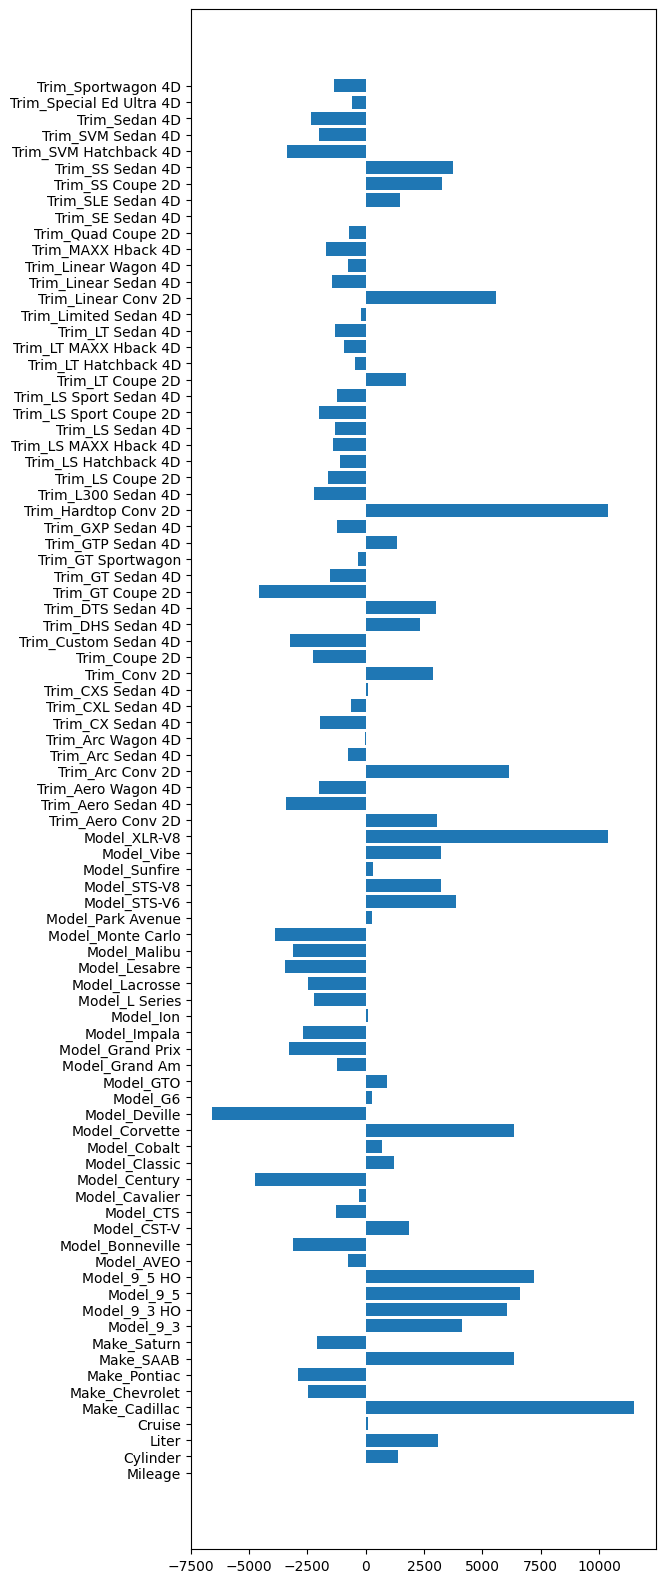

In [110]:
plt.figure(figsize=(6,20))
plt.barh(fi['Feature'],fi['Coef']);

In [112]:
# Residuals
# Used to analyze and visualize the model’s errors (residuals).

In [115]:
residuals=y_test - tahmin
# Residuals are calculated by subtracting the predicted values from the actual values.

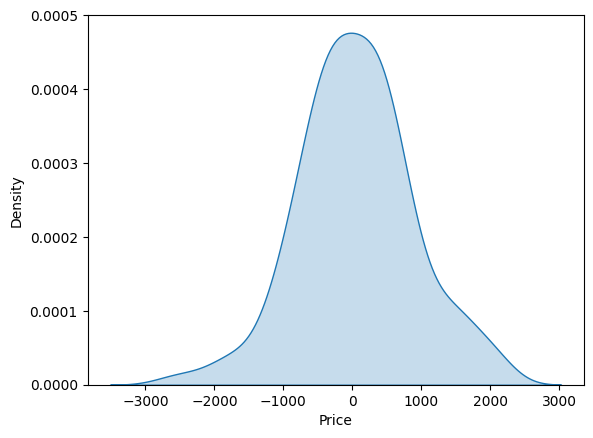

In [116]:
sns.kdeplot(x=residuals['Price'],fill=True);

In [117]:
residuals # Shows the error (difference) for each observation.

,Price
192,-628.669462
717,-474.519691
168,1097.670352
522,-129.048811
536,274.308031
...,...
658,-948.030491
356,-144.782474
525,-795.292375
748,-780.388924


In [134]:
#pip install yellowbrick

In [135]:
from yellowbrick.regressor import ResidualsPlot

/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



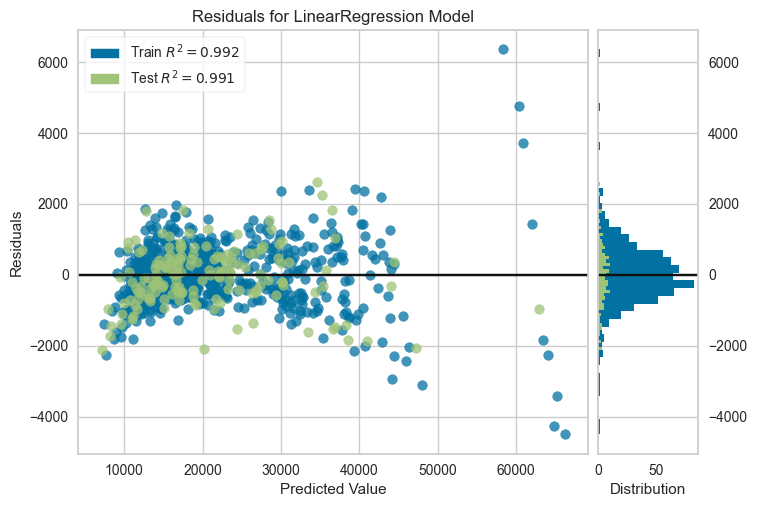

In [136]:
vis= ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show()
plt.show()

In [138]:
from sklearn.linear_model import Ridge,Lasso,ElasticNet

In [139]:
R=Ridge()
L=Lasso()
E=ElasticNet()

In [140]:
R.fit(x_train,y_train)
L.fit(x_train,y_train)
E.fit(x_train,y_train)

/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.458e+08, tolerance: 6.560e+06



,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [141]:
Rtahmin=R.predict(x_test)
Ltahmin=L.predict(x_test)
Etahmin=E.predict(x_test)

In [142]:
r2_score(y_test,Rtahmin)

0.9894464845619059

In [143]:
r2_score(y_test,Ltahmin)

0.9913274182884081

In [144]:
r2_score(y_test,Etahmin)

0.5943984117147725

<img src='https://cdn.educba.com/academy/wp-content/uploads/2019/05/Normalization-Formula.jpg' width='300'>

In [118]:
# Normalization: treating each feature equally by scaling values to a smaller range instead of large numbers.
# This helps reduce computational load and improves model performance.

In [119]:
from sklearn.preprocessing import MinMaxScaler

In [120]:
x=MinMaxScaler().fit_transform(x)
# All independent variables were scaled to a range between 0 and 1.

In [121]:
x

array([[0.15871591, 0.5       , 0.34090909, ..., 1.        , 0.        ,
        0.        ],
       [0.17695178, 0.5       , 0.34090909, ..., 1.        , 0.        ,
        0.        ],
       [0.2579757 , 0.5       , 0.34090909, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.40338381, 0.5       , 0.31818182, ..., 0.        , 0.        ,
        0.        ],
       [0.5130185 , 0.5       , 0.31818182, ..., 0.        , 0.        ,
        0.        ],
       [0.70621097, 0.5       , 0.31818182, ..., 0.        , 0.        ,
        0.        ]])

In [122]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [123]:
# Non-linear models

In [124]:
from sklearn.tree import DecisionTreeRegressor

In [125]:
dt=DecisionTreeRegressor()

In [126]:
dt.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [127]:
dtahmin=dt.predict(x_test)

In [128]:
r2_score(y_test,dtahmin)

0.9762511983884594

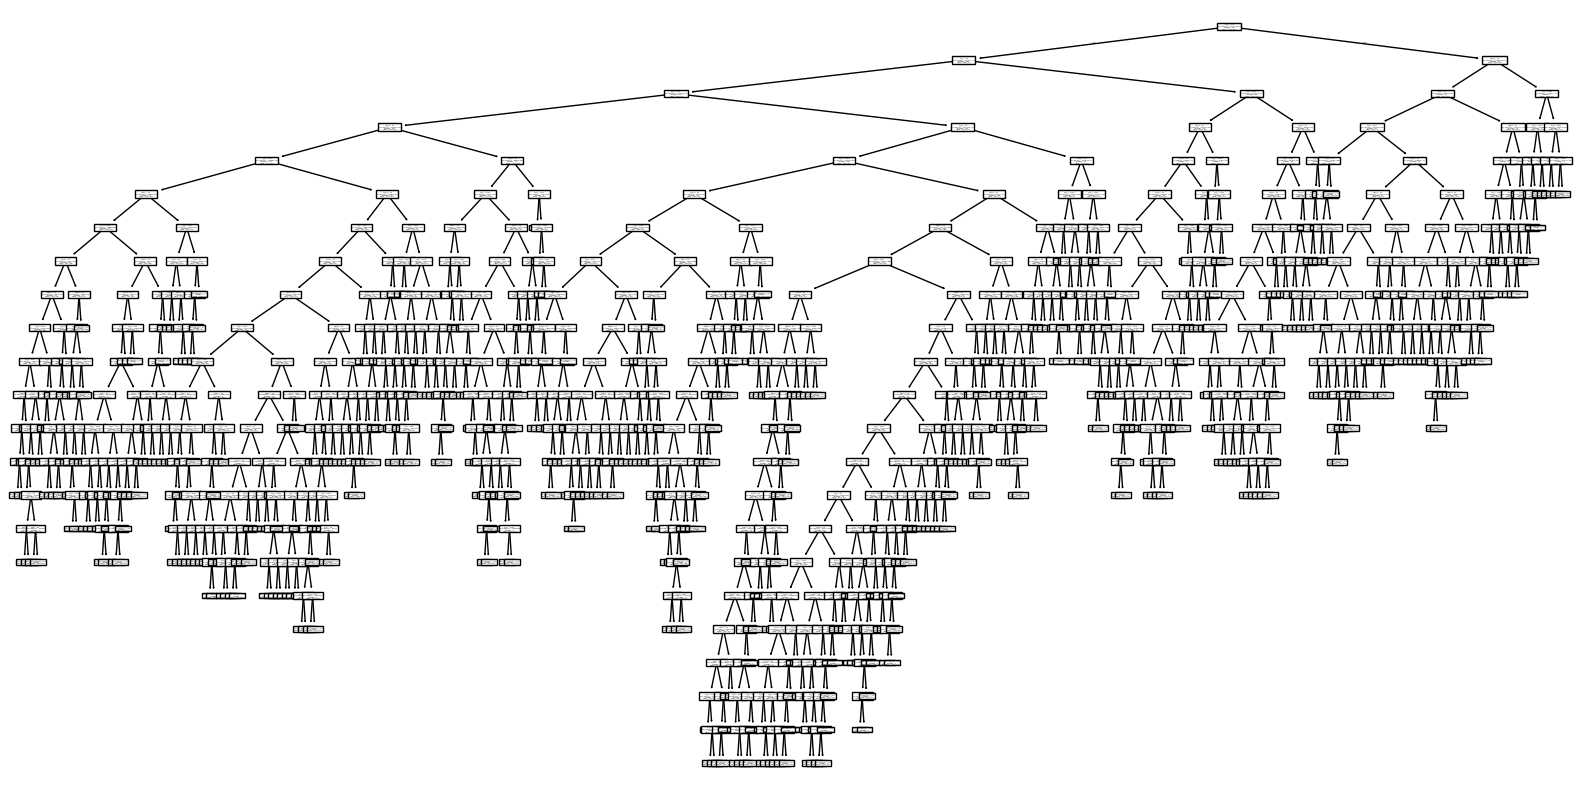

In [129]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt);

In [130]:
from sklearn.ensemble import ExtraTreesRegressor

In [131]:
ET=ExtraTreesRegressor()

In [132]:
ET.fit(x_train,y_train)

/Users/nbarcin/anaconda3/envs/yeni_env/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [133]:
Etahmin=ET.predict(x_test)

In [134]:
r2_score(y_test,Etahmin)

0.9940770840593889

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [136]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Lasso,0.991279,831.705401,645.408225
Linear,0.991189,835.989988,647.602077
SGD,0.990061,887.859480,681.283511
XGBRegressor,0.989899,895.055236,610.310974
Ridge,0.989474,913.722896,704.077074
Extra Tree,0.987250,1005.613663,743.353371
Gradient Boosting,0.981538,1210.072292,967.777216
AdaBoost,0.978541,1304.624230,984.456075
Decision Tree,0.975406,1396.676584,873.849428
KNeighborsRegressor,0.862622,3300.923590,2748.572278


In [137]:
#pip install xgboost

In [138]:
#pip install catboost

In [139]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

# Linear / Regularized
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  SGDRegressor, HuberRegressor, RANSACRegressor,
                                  BayesianRidge, OrthogonalMatchingPursuit)
# Tree
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor, AdaBoostRegressor)
# Neighbors
from sklearn.neighbors import KNeighborsRegressor
# SVR / Kernel
from sklearn.svm import SVR, NuSVR
from sklearn.kernel_ridge import KernelRidge
# Neural Net
from sklearn.neural_network import MLPRegressor
# Boosting
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Yellowbrick
from yellowbrick.regressor import PredictionError, ResidualsPlot

# Suppress warnings
warnings.filterwarnings("ignore")

def algo_test(x, y, plot=True, yellowbrick_viz=False):
    # ======================
    # Define Regression Models
    # ======================
    algos = [
        LinearRegression(),
        Ridge(),
        Lasso(),
        ElasticNet(),
        SGDRegressor(max_iter=1000, tol=1e-3),
        HuberRegressor(),
        RANSACRegressor(),
        BayesianRidge(),
        OrthogonalMatchingPursuit(),
        ExtraTreeRegressor(),
        DecisionTreeRegressor(),
        RandomForestRegressor(),
        GradientBoostingRegressor(),
        HistGradientBoostingRegressor(),
        AdaBoostRegressor(),
        XGBRegressor(verbosity=0, n_jobs=-1),
        CatBoostRegressor(verbose=0),
        KNeighborsRegressor(),
        SVR(),
        NuSVR(),
        KernelRidge(),
        MLPRegressor(max_iter=500, hidden_layer_sizes=(100,50))
    ]

    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 
        'Huber', 'RANSAC', 'BayesianRidge', 'OMP',
        'Extra Tree', 'Decision Tree', 'Random Forest', 'Gradient Boosting',
        'HistGradientBoosting', 'AdaBoost', 'XGBoost', 'CatBoost',
        'KNN', 'SVR', 'NuSVR', 'KernelRidge', 'MLP'
    ]

    # ======================
    # Train/Test Split
    # ======================
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.20, random_state=42
    )

    results = []

    # ======================
    # Fit Models & Evaluate
    # ======================
    for name, algo in zip(algo_names, algos):
        try:
            # Scale only non-tree models
            if name not in ['Extra Tree', 'Decision Tree', 'Random Forest',
                            'Gradient Boosting', 'HistGradientBoosting',
                            'AdaBoost', 'XGBoost', 'CatBoost']:
                scaler = MinMaxScaler()
                x_train_scaled = scaler.fit_transform(x_train)
                x_test_scaled = scaler.transform(x_test)
            else:
                x_train_scaled = x_train
                x_test_scaled = x_test

            # Fit and predict
            preds = algo.fit(x_train_scaled, y_train).predict(x_test_scaled)
            r2 = r2_score(y_test, preds)
            rmse = mean_squared_error(y_test, preds)
        except Exception as e:
            r2 = None
            rmse = None
            print(f"Model {name} failed: {e}")

        results.append({
            "Model": name,
            "R2": r2,
            "RMSE": rmse
        })

        # ======================
        # Yellowbrick visualizations
        # ======================
        if yellowbrick_viz:
            try:
                # Prediction Error
                plt.figure(figsize=(10, 6))
                visualizer = PredictionError(algo)
                visualizer.fit(x_train_scaled, y_train)
                visualizer.score(x_test_scaled, y_test)
                visualizer.show()

                # Residuals Plot
                plt.figure(figsize=(10, 6))
                visualizer = ResidualsPlot(algo)
                visualizer.fit(x_train_scaled, y_train)
                visualizer.score(x_test_scaled, y_test)
                visualizer.show()

            except Exception as e:
                print(f"Yellowbrick visualizations for {name} failed: {e}")

    # ======================
    # Results Table
    # ======================
    result_df = pd.DataFrame(results).sort_values("R2", ascending=False)
    
    print("\n=== Regression Model Comparison ===\n")
    print(result_df.reset_index(drop=True))

    # ======================
    # Seaborn Plots
    # ======================
    if plot:
        plt.figure(figsize=(18, 7))

        # R2 Score
        plt.subplot(1, 2, 1)
        sns.barplot(data=result_df, x="Model", y="R2", palette="viridis")
        plt.title("R² Score Comparison (Higher is Better)")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis="y", alpha=0.3)

        # RMSE
        plt.subplot(1, 2, 2)
        sns.barplot(data=result_df, x="Model", y="RMSE", palette="magma")
        plt.title("RMSE Comparison (Lower is Better)")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

        # RMSE vs R2 scatter
        plt.figure(figsize=(12, 6))
        sns.scatterplot(data=result_df, x="RMSE", y="R2", hue="Model", s=150)
        for i, row in result_df.iterrows():
            plt.text(row["RMSE"], row["R2"], row["Model"], fontsize=9)
        plt.title("Regression Model Trade-off: RMSE vs R²")
        plt.xlabel("RMSE (Lower is Better)")
        plt.ylabel("R² (Higher is Better)")
        plt.grid(alpha=0.3)
        plt.show()

    return result_df


=== Regression Model Comparison ===

                   Model        R2          RMSE
0               CatBoost  0.995453  3.606245e+05
1                  Huber  0.991554  6.698915e+05
2                  Lasso  0.991278  6.917820e+05
3          BayesianRidge  0.991273  6.921746e+05
4                 Linear  0.991189  6.988793e+05
5                 RANSAC  0.991033  7.112381e+05
6                    SGD  0.990055  7.888089e+05
7             Extra Tree  0.989987  7.941948e+05
8                XGBoost  0.989899  8.011239e+05
9                  Ridge  0.989471  8.350965e+05
10         Random Forest  0.985310  1.165149e+06
11           KernelRidge  0.985298  1.166112e+06
12     Gradient Boosting  0.981546  1.463695e+06
13                   KNN  0.978541  1.702044e+06
14         Decision Tree  0.978540  1.702093e+06
15  HistGradientBoosting  0.955434  3.534757e+06
16                   OMP  0.910628  7.088519e+06
17              AdaBoost  0.890648  8.673205e+06
18                   MLP  0.875

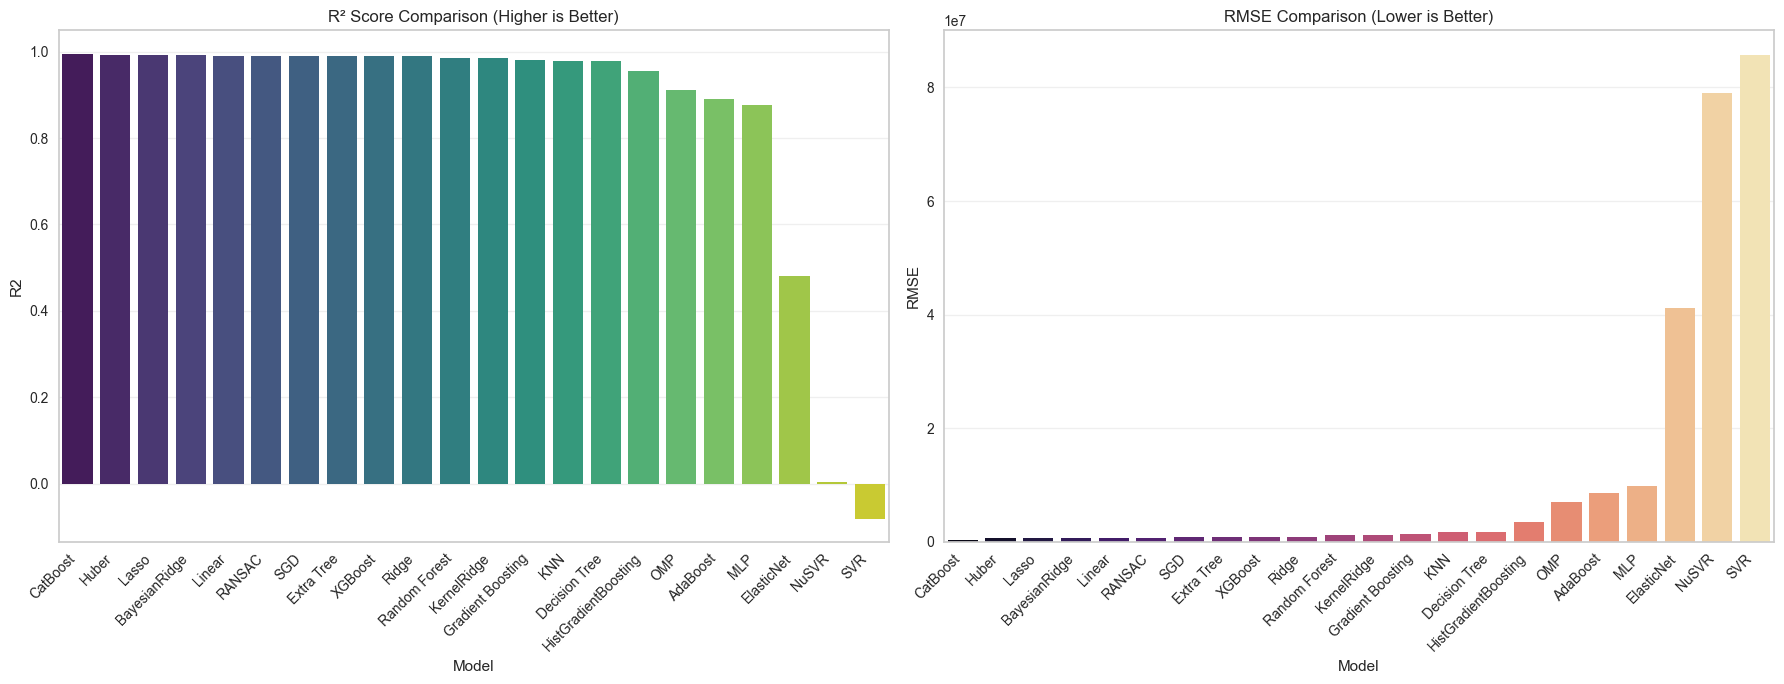

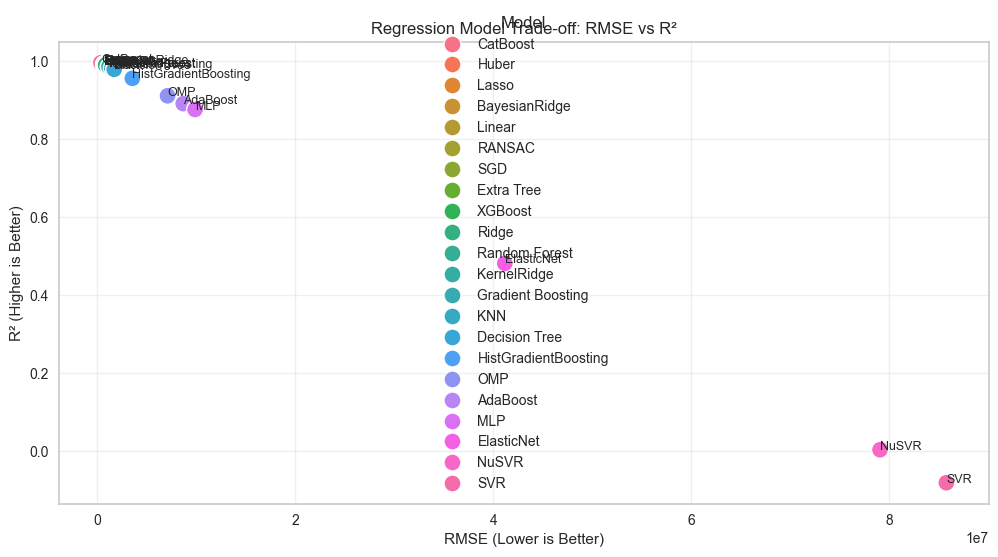

,Model,R2,RMSE
16,CatBoost,0.995453,3.606245e+05
5,Huber,0.991554,6.698915e+05
2,Lasso,0.991278,6.917820e+05
7,BayesianRidge,0.991273,6.921746e+05
0,Linear,0.991189,6.988793e+05
6,RANSAC,0.991033,7.112381e+05
4,SGD,0.990055,7.888089e+05
9,Extra Tree,0.989987,7.941948e+05
15,XGBoost,0.989899,8.011239e+05
1,Ridge,0.989471,8.350965e+05


In [140]:
algo_test(x,y)

### Conclusion

In this project, we developed a machine learning model to predict car prices with an impressive accuracy of 99.54%.

We evaluated a total of 21 different regression models, comparing their performance to identify the most effective approach. Among all models, CatBoost Regressor outperformed the others and delivered the best results.

Our final model significantly exceeded the target performance, achieving a strong improvement of 14 points above the baseline, demonstrating the effectiveness of our feature engineering and model selection process.

Overall, this project highlights the power of advanced ensemble methods like CatBoost in handling structured data and delivering high-accuracy predictions.